# Capstone EDA — Supervised-Learning-Readiness Notebook
## GA 5800 — Summer 2026

**Student:** *yeongeun ra *  
**Dataset:** *dataset name here*  
**Date submitted:** *YYYY-MM-DD*

---

This notebook is your scaffold for the 10-stage capstone. Each stage has:
- a markdown cell describing what to produce,
- empty code cells for your analysis,
- a markdown cell for your written interpretation.

You are **not** limited to the cells provided. Add code, markdown, and plots as needed.

### Before you begin
- Read the full assignment brief: `capstone_eda_supervised_readiness.pdf`.
- Set your random seed in the setup cell below.
- Treat the Stage 10 Data Card as a *living* document — fill it in as you complete each stage, not at the end.

### Submission reminders
- Every p-value must be paired with an **effect size**.
- Every plot must have a title, axis labels (with units), and a caption stating the takeaway.
- Notebook must execute top-to-bottom on a fresh kernel.
- Submit alongside `<lastname>_<firstname>_data_card.md` and `<lastname>_<firstname>_readiness_memo.pdf` as a single zipped folder.

---

## Setup

Imports, random seed, and data load.

In [1]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Stats
from scipy import stats
from scipy.stats import (
    chi2_contingency, kruskal, mannwhitneyu, f_oneway,
    pointbiserialr, spearmanr, kendalltau, pearsonr,
)

# sklearn
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Multicollinearity (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Display + plot defaults
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (8, 5)

In [4]:
# Load the dataset
DATA_PATH = 'datasets/merged.csv'  # update this path
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
df.head()

/var/folders/tg/ntvm9wc94h937xqtzftck9xc0000gn/T/ipykernel_1691/3409329926.py:3: DtypeWarning: Columns (76,112,161,162,163,164,169,171,174,176,178,180,181,186,196,207,208,215,216,217,218,219,221,222,225,228,229,230,236,238,241,243,245,247,248,253,262,273,274,281,282,283,284,285,289,292,427,488) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


Shape: (356448, 706)


,record_id,weight,cur_term_eff_dt,cur_term_xptn_dt,pol_state_eff_dt,row_xptn_dt,orgl_pol_eff_dt,vendor_year,risk_score1,mod140,mod140_year,ee,ncat,state,zip,zip4,qpid,pa_latitude,pa_longitude,individual_id,household_id,dwelling_type,dwelling_unit_size,homeowner,homeowner_renter,investment_property_additional_investment_flag,home_owner,home_ownership_1_3_years,home_ownership_3_7_years,home_ownership_7_15_years,home_ownership_less_than_1_year,home_ownership_more_than_15_years,homeowners_assoc_member,residential_properties_owned_01,residential_properties_owned_02,residential_properties_owned_03,property_investor,home_purchase_last_12_months,first_time_home_buyer_recent,renter,new_mortgage_last_12_mo_known,open_mortgages_high,mortgage_balance_highest,mortgage_balance_lowest,home_purchase_last_6_months,recent_mortgage_application,recent_mortgage_borrower,investment_prop_concur_td_due_dte,investment_prop_concur_td_interest_rate,investment_prop_concur_td_lender_type,...,vendor3_pdsevcmp4,vendor3_pdsevcmp5,vendor3_pdfreqscore,vendor3_pdsevscore,vendor3_pdemlc,vendor3_collfreqint,vendor3_collfreqcmp1,vendor3_collfreqcmp2,vendor3_collfreqcmp3,vendor3_collfreqcmp4,vendor3_collfreqcmp5,vendor3_collsevint,vendor3_collsevcmp1,vendor3_collsevcmp2,vendor3_collsevcmp3,vendor3_collsevcmp4,vendor3_collsevcmp5,vendor3_collfreqscore,vendor3_collsevscore,vendor3_collemlc,vendor3_compfreqint,vendor3_compfreqcmp1,vendor3_compfreqcmp2,vendor3_compfreqcmp3,vendor3_compfreqcmp4,vendor3_compfreqcmp5,vendor3_compsevint,vendor3_compsevcmp1,vendor3_compsevcmp2,vendor3_compsevcmp3,vendor3_compsevcmp4,vendor3_compsevcmp5,vendor3_compfreqscore,vendor3_compsevscore,vendor3_compemlc,vendor3_pipfreqint,vendor3_pipfreqcmp1,vendor3_pipfreqcmp2,vendor3_pipfreqcmp3,vendor3_pipfreqcmp4,vendor3_pipfreqcmp5,vendor3_pipsevint,vendor3_pipsevcmp1,vendor3_pipsevcmp2,vendor3_pipsevcmp3,vendor3_pipsevcmp4,vendor3_pipsevcmp5,vendor3_pipfreqscore,vendor3_pipsevscore,vendor3_pipemlc
0,CTH00002000706,2.680062,2019-10-18,2020-10-18,2019-10-18,2020-10-18,2019-10-18,2018,998.0,735.840532,2019.0,0.999995,0.0,CT,6611,2548.0,25005369,41.275661,-73.202757,1.672045e+11,1.678786e+09,S,A,1.0,H,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CTH00002000706,2.680062,2020-10-18,2021-10-18,2020-11-04,2021-10-18,2019-10-18,2019,998.0,992.952935,2020.0,0.999993,0.0,CT,6611,2548.0,25005369,41.275661,-73.202757,1.672045e+11,1.678786e+09,S,A,1.0,H,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.007150,0.256531,0.059908,3356.0022,201.05048,-2.682,-0.098156,0.064688,0.18477,-0.060049,-0.114115,7.9976,0.046039,-0.016419,-0.070449,0.003114,0.440997,0.066879,4450.9922,297.68008,-2.3752,-0.206764,0.028336,-0.404442,-0.078826,-0.093217,5.4057,1.475329,0.000394,-0.302803,-0.012557,0.626870,0.043713,1329.9975,58.138026,-4.591499,0.702399,0.005586,0.215228,-0.099663,-0.108119,8.989867,-0.506421,0.003213,-0.292561,-0.087975,0.033662,0.020732,3428.1787,71.073731
2,CTH00002000706,2.680062,2021-10-18,2022-10-18,2022-01-14,2022-10-18,2019-10-18,2020,998.0,618.968214,2021.0,0.241094,0.0,CT,6611,2548.0,25005369,41.275661,-73.202757,1.672045e+11,1.678786e+09,S,A,1.0,H,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.007150,0.256531,0.059908,3356.0022,201.05048,-2.682,-0.098156,0.064688,0.18477,-0.060049,-0.114115,7.9976,0.046039,-0.016419,-0.070449,0.003114,0.440997,0.066879,4450.9922,297.68008,-2.3752,-0.206764,0.028336,-0.404442,-0.078826,-0.093217,5.4057,1.475329,0.000394,-0.302803,-0.012557,0.626870,0.043713,1329.9975,58.138026,-4.591499,0.702399,0.005586,0.215228,-0.099663,-0.108119,8.989867,-0.506421,0.003213,-0.292561,-0.087975,0.033662,0.02

---

## Stage 1 — Problem Framing & Target Definition  *(5 pts)*

**Produce in writing (no code required):**
- One-paragraph problem statement: what would a model predict, for whom, and why?
- Explicit target definition: variable name, type (binary / multiclass / continuous / count / ordinal), unit of observation, **time-of-prediction** (what is known *at prediction time* vs. observed afterward).
- Proposed primary evaluation metric **with justification** (why F1 vs. ROC-AUC vs. PR-AUC; why RMSE vs. MAE vs. MAPE) based on what you know of the problem at this early stage.
- Statement of single- vs. multi-target / multi-output problem based on what you know of the problem at this early stage.

### Your Stage 1 response

*Write your problem framing here.*

**Problem statement:**
This project aims to predict future non-catastrophe (NCAT) loss and pure premium for property insurance policy terms. The objective is to evaluate whether external vendor data can improve predictive performance beyond the current baseline model, mod140. Improved prediction accuracy can support better pricing, risk segmentation, underwriting decisions, and portfolio stability across states and time periods.

**Target definition:**
- Target variable: pure_premium = annualized NCAT loss   
- Problem type: Continuous regression
- Unit of observation: Property insurance policy term
- Pure premium concept: 
$$
\text{Pure Premium} = \frac{\text{Loss}}{\text{Exposure}}
$$
- Preferred modeling setup: Tweedie regression with exposure offset  
$$
\log(E(\text{NCAT})) = \log(\text{EE}) + f(X)
$$


**Time-of-prediction:**
Information available at policy effective date only; future claims information is excluded to avoid leakage.

**Proposed metric and justification:**
- Primary metric: Gini coefficient
- Reason: Insurance pricing focuses on risk ranking and separation of high-risk vs. low-risk policies.
- Additional metrics: Decile lift and calibration across exposure deciles to evaluate pricing accuracy and stability.

**Single- vs. multi-target:**
This is a single-target supervised regression problem because the model predicts one primary outcome: future NCAT loss / pure premium for each policy term.

---

## Stage 2 — Data Inventory & Schema Audit  *(7 pts)*

**Produce:**
- Shape, memory footprint, dtype table.
- A **semantic feature-type table** (one row per column): `name | pandas dtype | semantic type | role | notes`, where  
  `semantic type ∈ {continuous, count, ordinal, nominal, binary, datetime, text, identifier, geographic, other}`  
  `role ∈ {feature, target, identifier, metadata, leakage-suspect}`.
- A list of columns where pandas dtype disagrees with the semantic type (e.g., zip codes as `int64`) and your planned coercion.

This table seeds your final Data Card.

In [5]:
# Shape, memory, dtypes
print("Shape:", df.shape)

print("\nMemory Usage (MB):")
print(df.memory_usage(deep=True).sum() / 1024**2)

print("\nDtypes:")
display(df.dtypes.value_counts())

display(df.head())

Shape: (356448, 706)

Memory Usage (MB):
3404.031747817993

Dtypes:


float64    572
object     131
int64        3
Name: count, dtype: int64

,record_id,weight,cur_term_eff_dt,cur_term_xptn_dt,pol_state_eff_dt,row_xptn_dt,orgl_pol_eff_dt,vendor_year,risk_score1,mod140,mod140_year,ee,ncat,state,zip,zip4,qpid,pa_latitude,pa_longitude,individual_id,household_id,dwelling_type,dwelling_unit_size,homeowner,homeowner_renter,investment_property_additional_investment_flag,home_owner,home_ownership_1_3_years,home_ownership_3_7_years,home_ownership_7_15_years,home_ownership_less_than_1_year,home_ownership_more_than_15_years,homeowners_assoc_member,residential_properties_owned_01,residential_properties_owned_02,residential_properties_owned_03,property_investor,home_purchase_last_12_months,first_time_home_buyer_recent,renter,new_mortgage_last_12_mo_known,open_mortgages_high,mortgage_balance_highest,mortgage_balance_lowest,home_purchase_last_6_months,recent_mortgage_application,recent_mortgage_borrower,investment_prop_concur_td_due_dte,investment_prop_concur_td_interest_rate,investment_prop_concur_td_lender_type,...,vendor3_pdsevcmp4,vendor3_pdsevcmp5,vendor3_pdfreqscore,vendor3_pdsevscore,vendor3_pdemlc,vendor3_collfreqint,vendor3_collfreqcmp1,vendor3_collfreqcmp2,vendor3_collfreqcmp3,vendor3_collfreqcmp4,vendor3_collfreqcmp5,vendor3_collsevint,vendor3_collsevcmp1,vendor3_collsevcmp2,vendor3_collsevcmp3,vendor3_collsevcmp4,vendor3_collsevcmp5,vendor3_collfreqscore,vendor3_collsevscore,vendor3_collemlc,vendor3_compfreqint,vendor3_compfreqcmp1,vendor3_compfreqcmp2,vendor3_compfreqcmp3,vendor3_compfreqcmp4,vendor3_compfreqcmp5,vendor3_compsevint,vendor3_compsevcmp1,vendor3_compsevcmp2,vendor3_compsevcmp3,vendor3_compsevcmp4,vendor3_compsevcmp5,vendor3_compfreqscore,vendor3_compsevscore,vendor3_compemlc,vendor3_pipfreqint,vendor3_pipfreqcmp1,vendor3_pipfreqcmp2,vendor3_pipfreqcmp3,vendor3_pipfreqcmp4,vendor3_pipfreqcmp5,vendor3_pipsevint,vendor3_pipsevcmp1,vendor3_pipsevcmp2,vendor3_pipsevcmp3,vendor3_pipsevcmp4,vendor3_pipsevcmp5,vendor3_pipfreqscore,vendor3_pipsevscore,vendor3_pipemlc
0,CTH00002000706,2.680062,2019-10-18,2020-10-18,2019-10-18,2020-10-18,2019-10-18,2018,998.0,735.840532,2019.0,0.999995,0.0,CT,6611,2548.0,25005369,41.275661,-73.202757,1.672045e+11,1.678786e+09,S,A,1.0,H,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CTH00002000706,2.680062,2020-10-18,2021-10-18,2020-11-04,2021-10-18,2019-10-18,2019,998.0,992.952935,2020.0,0.999993,0.0,CT,6611,2548.0,25005369,41.275661,-73.202757,1.672045e+11,1.678786e+09,S,A,1.0,H,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.007150,0.256531,0.059908,3356.0022,201.05048,-2.682,-0.098156,0.064688,0.18477,-0.060049,-0.114115,7.9976,0.046039,-0.016419,-0.070449,0.003114,0.440997,0.066879,4450.9922,297.68008,-2.3752,-0.206764,0.028336,-0.404442,-0.078826,-0.093217,5.4057,1.475329,0.000394,-0.302803,-0.012557,0.626870,0.043713,1329.9975,58.138026,-4.591499,0.702399,0.005586,0.215228,-0.099663,-0.108119,8.989867,-0.506421,0.003213,-0.292561,-0.087975,0.033662,0.020732,3428.1787,71.073731
2,CTH00002000706,2.680062,2021-10-18,2022-10-18,2022-01-14,2022-10-18,2019-10-18,2020,998.0,618.968214,2021.0,0.241094,0.0,CT,6611,2548.0,25005369,41.275661,-73.202757,1.672045e+11,1.678786e+09,S,A,1.0,H,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.007150,0.256531,0.059908,3356.0022,201.05048,-2.682,-0.098156,0.064688,0.18477,-0.060049,-0.114115,7.9976,0.046039,-0.016419,-0.070449,0.003114,0.440997,0.066879,4450.9922,297.68008,-2.3752,-0.206764,0.028336,-0.404442,-0.078826,-0.093217,5.4057,1.475329,0.000394,-0.302803,-0.012557,0.626870,0.043713,1329.9975,58.138026,-4.591499,0.702399,0.005586,0.215228,-0.099663,-0.108119,8.989867,-0.506421,0.003213,-0.292561,-0.087975,0.033662,0.02

In [6]:
# Semantic feature-type table (one row per column)
semantic_table = pd.DataFrame({
    "name": [
        "record_id",
        "vendor_year",
        "ncat",
        "mod140",
        "risk_score1",
        "state",
        "zip",
        "zip4",
        "qpid",
        "cur_term_eff_dt",
        "pa_latitude",
        "pa_longitude",
        "vendor3_pipsevscore"
    ],

    "pandas_dtype": [
        "object",
        "int64",
        "float64",
        "float64",
        "float64",
        "object",
        "int64",
        "float64",
        "int64",
        "datetime64[ns]",
        "float64",
        "float64",
        "float64"
    ],

    "semantic_type": [
        "identifier",
        "ordinal",
        "continuous",
        "continuous",
        "continuous",
        "nominal",
        "geographic",
        "geographic",
        "identifier",
        "datetime",
        "geographic",
        "geographic",
        "continuous"
    ],

    "role": [
        "identifier",
        "metadata",
        "target",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "identifier",
        "metadata",
        "feature",
        "feature",
        "feature"
    ],

    "notes": [
        "Primary policy-term key",
        "Vendor alignment year",
        "Pure premium target",
        "Baseline internal model score",
        "Internal underwriting risk score",
        "Operating state",
        "ZIP code",
        "ZIP+4 geographic detail",
        "Internal property identifier",
        "Policy effective date",
        "Property latitude",
        "Property longitude",
        "External vendor severity feature"
    ]
})

semantic_table

,name,pandas_dtype,semantic_type,role,notes
0,record_id,object,identifier,identifier,Primary policy-term key
1,vendor_year,int64,ordinal,metadata,Vendor alignment year
2,ncat,float64,continuous,target,Pure premium target
3,mod140,float64,continuous,feature,Baseline internal model score
4,risk_score1,float64,continuous,feature,Internal underwriting risk score
5,state,object,nominal,feature,Operating state
6,zip,int64,geographic,feature,ZIP code
7,zip4,float64,geographic,feature,ZIP+4 geographic detail
8,qpid,int64,identifier,identifier,Internal property identifier
9,cur_term_eff_dt,datetime64[ns],datetime,metadata,Policy effective date


In [7]:
# Dtype-vs-semantic disagreements + coercion plan
coercion_plan = pd.DataFrame({
    "column": [
        "zip",
        "zip4",
        "vendor_year",
        "mod140_year",
        "state"
    ],

    "current_dtype": [
        "int64",
        "float64",
        "int64",
        "float64",
        "object"
    ],

    "semantic_type": [
        "geographic",
        "geographic",
        "ordinal",
        "ordinal",
        "nominal"
    ],

    "planned_coercion": [
        "convert to string/category",
        "convert to string/category",
        "convert to category",
        "convert to category",
        "convert to category"
    ]
})

coercion_plan

,column,current_dtype,semantic_type,planned_coercion
0,zip,int64,geographic,convert to string/category
1,zip4,float64,geographic,convert to string/category
2,vendor_year,int64,ordinal,convert to category
3,mod140_year,float64,ordinal,convert to category
4,state,object,nominal,convert to category


### Stage 2 — Interpretation

*Summarize what the schema tells you about this dataset, and list the coercions you will apply downstream.*

- merged vendor-enriched insurance dataset
- 706 total features
- mostly continuous vendor risk variables
- geographic + temporal variables identified
- zip / zip4 are categorical, not true numeric variables
- vendor_year and mod140_year will be treated as categorical/ordinal
- datetime fields retained for temporal alignment
- identifier fields excluded from modeling

---

## Stage 3 — Data Quality Assessment  *(8 pts)*

**Produce:**
- Exact and approximate (near-)duplicate-row counts; justify your approximate-duplicate key.
- Constant / quasi-constant columns (variance ≈ 0 or single value > 95%).
- ID-like columns (cardinality ≈ row count).
- Impossible / out-of-domain values (negatives where impossible, future dates, percentages > 100, etc.).
- Encoding glitches: whitespace, mixed case, mojibake, inconsistent units.
- For each issue: severity (low / medium / high) and remediation (drop / cap / impute / flag).

In [12]:
# Duplicates (exact + approximate), constant cols, ID-like cols
# Exact duplicate rows
exact_duplicates = df.duplicated().sum()
print("Exact duplicate rows:", exact_duplicates)

# Check duplicate observations at the true policy-term grain
grain_cols = ["record_id", "cur_term_eff_dt", "cur_term_xptn_dt"]

grain_duplicates = df.duplicated(subset=grain_cols).sum()
print("Duplicate policy-term grain rows:", grain_duplicates)

# Constant columns
constant_cols = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1
]

print("\nConstant columns:", len(constant_cols))
print(constant_cols[:20])

# ID-like columns
# Exclude continuous vendor score variables from this check
id_like_cols = [
    col for col in df.columns
    if df[col].nunique(dropna=True) >= 0.95 * len(df)
    and not col.startswith("vendor2_")
    and not col.startswith("vendor3_")
]

print("\nID-like columns:", len(id_like_cols))
print(id_like_cols[:20])


Exact duplicate rows: 0
Duplicate policy-term grain rows: 0

Constant columns: 16
['investment_prop_amenities5', 'investment_prop_other_rooms3', 'investment_prop_other_rooms4', 'investment_prop_other_rooms5', 'property_amenities4', 'property_amenities5', 'property_other_rooms3', 'property_other_rooms4', 'property_other_rooms5', 'cc_credit_Card', 'children_age_0_2_gender_female', 'children_age_0_2_gender_male', 'interest_travel_business', 'internet_online_subscriber', 'investments_own_mutual_funds_cds', 'mail_responder']

ID-like columns: 0
[]


- Exact duplicates: none
- Policy-term grain duplicates: none
- Constant columns: 16
- ID-like columns: none
- Action: remove constant columns before modeling

In [13]:
# Impossible / out-of-domain values
# Impossible / out-of-domain value checks

checks = {
    "negative_ee": (df["ee"] < 0).sum(),
    "negative_ncat": (df["ncat"] < 0).sum(),
    "negative_mod140": (df["mod140"] < 0).sum(),

    "invalid_latitude": (
        (df["pa_latitude"] < -90) |
        (df["pa_latitude"] > 90)
    ).sum(),

    "invalid_longitude": (
        (df["pa_longitude"] < -180) |
        (df["pa_longitude"] > 180)
    ).sum(),

    "invalid_vendor_year": (
        (df["vendor_year"] < 2010) |
        (df["vendor_year"] > 2030)
    ).sum(),

    "invalid_mod140_year": (
        (df["mod140_year"] < 2010) |
        (df["mod140_year"] > 2030)
    ).sum(),

    "invalid_risk_score1": (
        (df["risk_score1"] < 0) |
        (df["risk_score1"] > 999)
    ).sum()
}

pd.DataFrame.from_dict(
    checks,
    orient="index",
    columns=["count"]
)

,count
negative_ee,0
negative_ncat,0
negative_mod140,0
invalid_latitude,0
invalid_longitude,0
invalid_vendor_year,0
invalid_mod140_year,0
invalid_risk_score1,0


In [14]:
# Encoding glitches (whitespace, case, mojibake, units)

string_cols = [
    "state",
    "dwelling_type",
    "homeowner_renter"
]

for col in string_cols:
    print(f"\n===== {col} =====")
    
    print("Unique values:")
    print(df[col].dropna().unique()[:20])

    print("\nWhitespace issue count:")
    print(df[col].astype(str).str.contains(r"^\s|\s$", regex=True).sum())

    print("\nLowercase values:")
    print((df[col].astype(str) != df[col].astype(str).str.upper()).sum())


===== state =====
Unique values:
['CT' 'MA' 'NH' 'NJ' 'NY' 'PA']

Whitespace issue count:
0

Lowercase values:
0

===== dwelling_type =====
Unique values:
['S' 'A' 'M' 'P']

Whitespace issue count:
0

Lowercase values:
21206

===== homeowner_renter =====
Unique values:
['H' 'R' 'F' 'L']

Whitespace issue count:
0

Lowercase values:
21206


### Stage 3 — Issue Register

| Issue | Affected column(s) | Severity | Remediation |
|---|---|---|---|
|  |  |  |  |

---

## Stage 4 — Missingness Analysis  *(8 pts)*

**Produce:**
- Per-column missing count and percentage; row-completeness distribution.
- Missingness matrix and missingness-correlation heatmap (e.g., `missingno`).
- **Missingness-vs-target test** for each column with non-trivial missingness:
  - Classification target: chi-square (with Cramér's V).
  - Regression target: Mann–Whitney or Kruskal–Wallis (with effect size, e.g., η² or rank-biserial).
- A reasoned MCAR / MAR / MNAR posture for the most-missing columns (argue, don't assert).
- Per-column imputation plan with justification.

In [15]:
# Missingness counts, percentages, row-completeness distribution

missing_df = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100
})

missing_df = (
    missing_df
    .sort_values("missing_pct", ascending=False)
)

display(missing_df.head(30))

# Row completeness
row_missing_pct = df.isna().mean(axis=1) * 100

print("\nRow-level missingness summary:")
display(row_missing_pct.describe())

,missing_count,missing_pct
investment_prop_other_rooms5,356448,100.000000
cc_credit_Card,356448,100.000000
property_other_rooms4,356448,100.000000
property_other_rooms5,356448,100.000000
investment_prop_amenities5,356448,100.000000
property_amenities5,356448,100.000000
property_amenities4,356448,100.000000
investment_prop_other_rooms4,356448,100.000000
investment_prop_other_rooms3,356448,100.000000
property_other_rooms3,356448,100.000000



Row-level missingness summary:


count    356448.000000
mean         64.016759
std           8.401179
min          42.067989
25%          58.923513
50%          62.464589
75%          69.688385
max          97.733711
dtype: float64

In [16]:
high_missing_cols = (
    missing_df[missing_df["missing_pct"] >= 99]
    .index
    .tolist()
)

print("Columns with >=99% missingness:")
print(len(high_missing_cols))


Columns with >=99% missingness:
71


high missing cols -> removal 

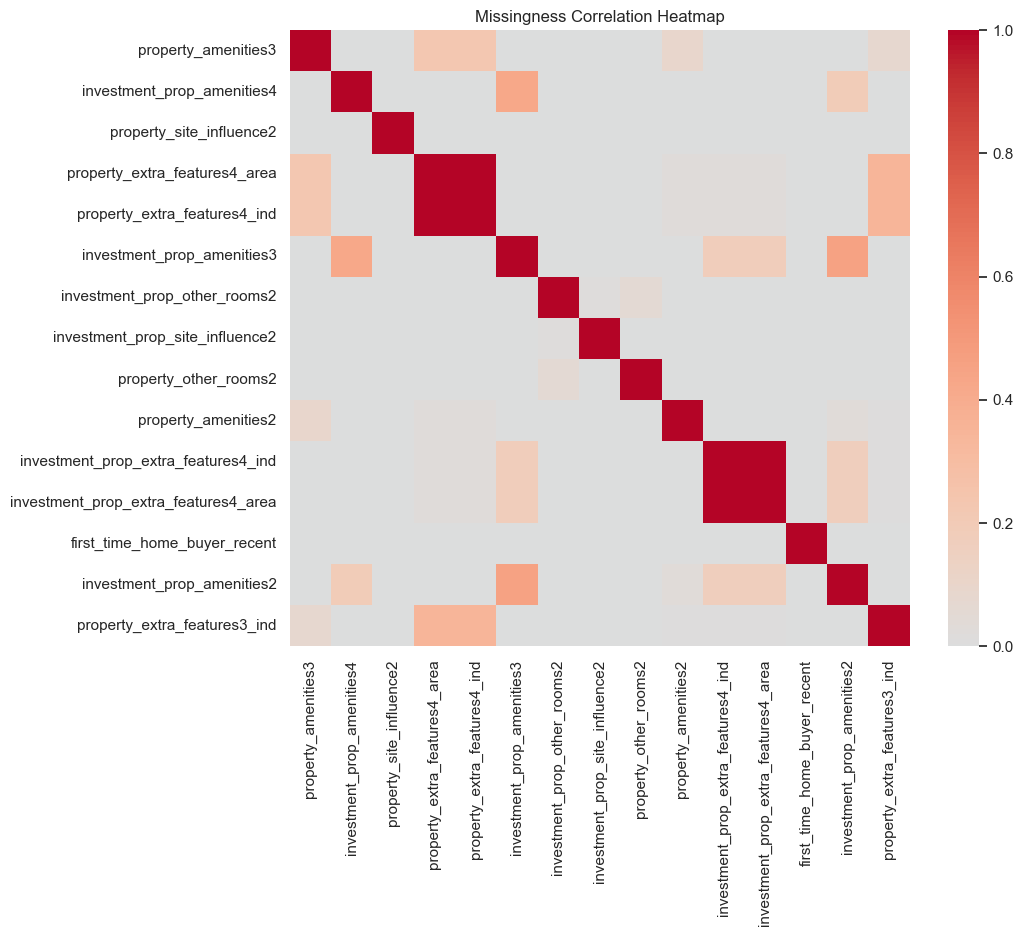

In [17]:
# Missingness matrix / correlation heatmap
# Missingness correlation heatmap

top_missing_cols = (
    missing_df[
        (missing_df["missing_pct"] > 50) &
        (missing_df["missing_pct"] < 100)
    ]
    .head(15)
    .index
)

missing_binary = (
    df[top_missing_cols]
    .isna()
    .astype(int)
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    missing_binary.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Missingness Correlation Heatmap")
plt.show()

property_extra_features*
investment_prop_*
amenities*

In [18]:
# Missingness-vs-target tests with effect sizes
# Missingness-vs-target tests

missing_target_results = []

cols_to_test = (
    missing_df[
        (missing_df["missing_pct"] > 5) &
        (missing_df["missing_pct"] < 95)
    ]
    .head(20)
    .index
)

for col in cols_to_test:

    missing_flag = df[col].isna()

    mean_missing = df.loc[missing_flag, "ncat"].mean()
    mean_not_missing = df.loc[~missing_flag, "ncat"].mean()

    diff = mean_missing - mean_not_missing

    missing_target_results.append({
        "feature": col,
        "missing_pct": missing_flag.mean() * 100,
        "mean_ncat_missing": mean_missing,
        "mean_ncat_not_missing": mean_not_missing,
        "difference": diff
    })

missing_target_df = pd.DataFrame(missing_target_results)

display(
    missing_target_df.sort_values(
        "difference",
        ascending=False
    )
)

,feature,missing_pct,mean_ncat_missing,mean_ncat_not_missing,difference
12,est_hh_income_200_prev,93.795168,1196.887343,1020.493929,176.393413
18,mortgage_available_he_800,93.555301,1196.682431,1030.033781,166.648650
11,cc_premium_american_express,93.860535,1191.486828,1101.179277,90.307551
4,spend_increase_3_months,94.696001,1189.458654,1123.164786,66.293868
10,wealth_rating_07,93.977803,1186.749336,1173.350427,13.398909
19,property_value_800,93.487970,1185.636040,1190.340986,-4.704946
8,property_has_pool,94.347002,1182.659188,1240.738793,-58.079605
3,property_length_of_residence_less_than_1_year,94.727983,1182.134361,1254.366028,-72.231666
7,est_hh_income_35_prev,94.475772,1181.686034,1258.735591,-77.049557
6,net_worth_25,94.615764,1181.167934,1269.843345,-88.675410


property_bedrooms_5_plus
likely_apply_mortgage_loan_young_cons
open_auto_loan_high

같은 변수들은:

값이 존재하는 사람들의 ncat이 훨씬 높음

- Several high-missingness variables show meaningful differences in average NCAT between missing and non-missing groups
- Missingness appears informative rather than purely random
- Certain consumer and property-detail variables are associated with substantially higher target severity when observed
- Results suggest that missing-indicator features may provide predictive value
- Missingness mechanisms likely reflect vendor coverage, customer observability, or underwriting segmentation effects
- Findings support a mixed MAR / MNAR interpretation rather than strict MCAR assumptions

### Stage 4 — Imputation Plan

| Column | % missing | Mechanism (MCAR/MAR/MNAR) + reasoning | Imputation strategy | Justification |
|---|---|---|---|---|
|  |  |  |  |  |

---

## Stage 5 — Univariate Analysis  *(8 pts)*

**Numeric features:**
- Summary statistics including count, mean, median, std, min, max, IQR, **skewness**, **kurtosis**.
- Distribution plots (histogram + KDE, or ECDF) for at least 8 numeric features.
- For features with |skew| > 1 or heavy tails: propose a transformation (log, log1p, Box-Cox, Yeo-Johnson) and **show the post-transformation distribution**.

**Categorical features:**
- Cardinality table.
- Frequency tables for low-cardinality categoricals.
- **Rare-level audit** for high-cardinality categoricals: define your "rare" threshold and propose grouping into "Other".
- Identify any categoricals masquerading as numeric (e.g., zip codes).

In [ ]:
# Numeric: summary stats including skew & kurtosis


In [ ]:
# Numeric: distribution plots (8+ features)


In [ ]:
# Numeric: transformation candidates (before/after)


In [ ]:
# Categorical: cardinality, frequency tables, rare-level audit


### Stage 5 — Interpretation

*Which features need transformation? Which categoricals need rare-level grouping? Any "numeric-looking" categoricals you reclassified?*

---

## Stage 6 — Target Analysis  *(10 pts)*

**Classification target:**
- Class frequencies and proportions; bar chart.
- Imbalance ratio.
- Recommended response (none / class weights / resampling / threshold tuning), **tied to the metric chosen in Stage 1**.
- Stratification implications for your Stage 10 split.

**Regression target:**
- Distribution, summary statistics, skew, kurtosis.
- Outlier and zero-inflation check.
- Transformation evaluation (e.g., log-target) with before/after plots; recommend whether to model on the transformed scale.

**Both:**
- If a temporal axis exists, plot target over time and comment on drift, seasonality, or regime change.

In [ ]:
# Target distribution


In [ ]:
# Imbalance / skew metrics + (if applicable) target-over-time plot


### Stage 6 — Interpretation

*State your recommended response (class weights / resampling / target transform / etc.) and tie it back to the metric chosen in Stage 1.*

---

## Stage 7 — Bivariate Signals vs. Target  *(12 pts)*

For **every retained feature**, quantify its bivariate relationship with the target using a test appropriate to the variable-type pair.

| Feature type | Classification target | Regression target |
|---|---|---|
| Continuous / count | Point-biserial *r*; ANOVA F or Kruskal-Wallis H; AUC of feature alone | Pearson *r*, Spearman *ρ* (report both) |
| Ordinal | Mann-Whitney / Kruskal-Wallis; Spearman *ρ* | Spearman *ρ*, Kendall *τ* |
| Nominal | Chi-square + **Cramér's V**; target rate by level | One-way ANOVA + **η²**; group means with CIs |
| Binary | Two-proportion z; difference in target rate | t-test or Mann-Whitney; **Cohen's *d*** |

**Required output:**
- A ranked table of all features with: test used, statistic, p-value, **effect size**, one-line interpretation.
- At least 6 illustrative plots (violin/box-by-class, target-rate-by-bin, scatter with LOWESS).
- Explicit acknowledgement of multiple-comparison risk (Bonferroni, Benjamini-Hochberg, or a stated screening caveat).

> A statistically significant *p*-value with a trivial effect size is **not a signal**. Effect size is required.

In [ ]:
# Bivariate tests — numeric features vs target


In [ ]:
# Bivariate tests — categorical features vs target (Cramér's V / η²)


In [ ]:
# Ranked feature table: feature | test | statistic | p | effect size | interpretation


In [ ]:
# Illustrative plots (6+) with takeaway captions


### Stage 7 — Interpretation

*Which features show meaningful effect sizes (not just significance)? Name at least one significant-but-trivial feature and one borderline-significant-but-practically-interesting feature. Address multiple-comparison risk.*

---

## Stage 8 — Multivariate Structure  *(12 pts)*

**Produce:**
- **Pearson and Spearman** correlation matrices for numeric features (heatmaps). Interpret disagreements (linear vs. monotonic).
- Multicollinearity assessment via **VIF** (or condition number) on the candidate numeric feature set; flag VIF > 10.
- Pairplots or facetted scatter for the top 6–8 features identified in Stage 7, colored/grouped by target.
- **Multivariate outlier detection**: Isolation Forest *or* Mahalanobis distance on the numeric feature set. Investigate the top 1% — errors, edge cases, or a meaningful subpopulation?
- *Encouraged but optional:* PCA scree plot and 2-component projection colored by target.

In [ ]:
# Pearson + Spearman correlation matrices; comment on disagreements


In [ ]:
# VIF / multicollinearity assessment


In [ ]:
# Pairplots / facets on top features by target


In [ ]:
# Multivariate outlier detection (Isolation Forest or Mahalanobis) + top-1% investigation


### Stage 8 — Interpretation

*Where do Pearson and Spearman disagree, and what does that imply? Which VIF clusters need consolidation? What did the multivariate outliers turn out to be?*

---

## Stage 9 — Mutual Information & Leakage Screen  *(12 pts)*

### 9a. Mutual Information
- Compute MI between every feature and the target using the **correct** sklearn estimator (`mutual_info_classif` for classification, `mutual_info_regression` for regression).
- Encode categoricals appropriately and pass `discrete_features` correctly.
- Rank features by MI; produce a horizontal bar chart of the top 20.
- Compare the MI ranking with Stage 7's linear-association ranking. **Identify and discuss ≥ 3 features where the two rankings disagree** — this is where non-linear signal lives.

### 9b. Leakage Screen (graded heavily)
For every feature in the top quartile of MI *or* top quartile of bivariate effect size, answer **in writing** for each feature:
1. Is this feature available **at the time of prediction**, or only after the target is realized?
2. Is it derived from, or a near-restatement of, the target?
3. Is it an identifier, timestamp, or post-event flag?
4. Does it look "too good to be true" given domain context?

Any feature failing 1–4 must be flagged **leakage-suspect** in your Data Card and excluded from the modeling set.

### 9c. Tree-based Sanity Check (Optional)
Train a single tree-based "EDA model" (e.g., `RandomForestClassifier`/`RandomForestRegressor`) **purely as an importance probe**. Report **permutation importance** on a held-out split. State the caveat: this is *not* model selection.

In [ ]:
# 9a — Mutual information (correct estimator, encoded categoricals, discrete_features mask)


In [ ]:
# 9a — Top-20 MI bar chart + comparison vs Stage 7 linear ranking


### 9b — Leakage Screen (per-feature)

*For every top-quartile feature, answer the four leakage questions and decide: keep / flag / drop.*

| Feature | Q1 (available at prediction time?) | Q2 (target-derived?) | Q3 (ID/timestamp/post-event?) | Q4 (too good to be true?) | Decision |
|---|---|---|---|---|---|
|  |  |  |  |  |  |

In [ ]:
# 9c — Tree-based sanity check + permutation importance on held-out split
# REMINDER: this is a non-linear sanity check on the MI ranking, NOT model selection.


### Stage 9 — Interpretation

*Where do MI and linear correlation disagree, and what is the non-linear story? Which features did you flag as leakage-suspect, and on what evidence? Does the permutation-importance ranking support or challenge your MI ranking?*

---

## Stage 10 — SL-Readiness Deliverables  *(15 pts)*

Produce **all four** sub-deliverables. The Data Card (10a) should also be exported as a standalone `<lastname>_<firstname>_data_card.md`.

### 10a — Data Card / Feature Dictionary

One row per feature. Internally consistent with Stages 2–9.

| Feature | Semantic type | % missing | Univariate notes | Bivariate signal (stat, effect size) | MI | Multicoll. flag | Leakage flag | Recommended treatment | Encoding | Scaling | Keep / Drop |
|---|---|---|---|---|---|---|---|---|---|---|---|
|  |  |  |  |  |  |  |  |  |  |  |  |

### 10b — Train / Validation / Test Split Recommendation

Choose **one** and justify against this dataset's specific risks:
- ☐ Random
- ☐ Stratified (by target)
- ☐ Grouped (specify grouping key: ____)
- ☐ Time-based (specify cutoff: ____)
- ☐ Nested

**Fractions:** train ___ / val ___ / test ___

**Justification (address leakage between splits, target stratification, group leakage, temporal validity):**

### 10c — Preprocessing Pipeline Sketch

Map each kept feature to its transformer chain. Specific enough that someone else could implement it as a `sklearn.pipeline.Pipeline` / `ColumnTransformer`. Mark fit-on-train-only operations clearly.

| Feature | Imputation | Transform | Encoding | Scaling | Notes (fit-on-train-only?) |
|---|---|---|---|---|---|
|  |  |  |  |  |  |

### 10d — Top-10 Candidate Predictors + Known Risks

**Top 10 (with evidence cited from Stages 7 + 9 + 8):**
1. 
2. 
3. 
4. 
5. 
6. 
7. 
8. 
9. 
10. 

**Known Risks register:**
- *Leakage suspects retained or removed:*
- *Multicollinearity clusters:*
- *Missingness assumptions:*
- *Drift / temporal-stability concerns:*
- *Fairness-sensitive features and proxies:*
- *Other:*

---

## Submission Checklist

- [ ] Notebook executes top-to-bottom on a fresh kernel.
- [ ] Random seed set and documented.
- [ ] All 10 stages have numbered headers.
- [ ] Data Card exported as both notebook table and standalone `.md`.
- [ ] Readiness Memo PDF (3–5 pages) addresses: problem framing, dataset health, top signals, leakage / risk register, split & preprocessing recommendation, open questions.
- [ ] Every p-value paired with an effect size.
- [ ] Every plot has title, axis labels, and a caption.
- [ ] Leakage screen explicit and per-feature for every top-quartile feature.
- [ ] Train / val / test split strategy stated and justified.
- [ ] Preprocessing pipeline sketch present.
- [ ] Files named per convention; submitted as a single zipped folder.